# Assignment 5: Social Network Analysis with R

**R Programming (ODD 2026-27)** | Purvaj Gaonkar | 23102C0083 | BE CMPN-C

Implementation of the workflow demonstrated in Bharatendra Rai's *Social Network
Analysis with R*.

**Objective.** Represent relationships between entities as a network, analyse its
structure, identify influential nodes, and visualise the result using `igraph`.

Set the runtime to R first: **Runtime -> Change runtime type -> R**, then Run all.
Unlike the previous assignment this notebook needs only one CRAN package, so setup
takes well under a minute.

In [1]:
R.version.string

[1] "R version 4.6.1 (2026-06-24)"

---
## Setup

In [2]:
options(repos = c(CRAN = "https://cloud.r-project.org"))
if (!requireNamespace("igraph", quietly = TRUE)) install.packages("igraph")
library(igraph)
packageVersion("igraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




[1] ‘2.3.3’

In [3]:
dir.create("output", showWarnings = FALSE)
options(repr.plot.width = 9, repr.plot.height = 7)

### A note on deprecated functions

The reference script was written for igraph 1.x. Four of the functions it uses have
since been renamed or deprecated, and one no longer returns the same structure. Each
substitution is marked in the code where it occurs.

| Tutorial | Current | Status |
|---|---|---|
| `graph()` | `make_graph()` | renamed |
| `graph.data.frame()` | `graph_from_data_frame()` | renamed |
| `hub_score()` | `hits_scores()$hub` | deprecated in igraph 2.0.3 |
| `authority.score()` | `hits_scores()$authority` | deprecated in igraph 2.1.0 |
| `layout.fruchterman.reingold` | `layout_with_fr` | renamed |
| `layout.kamada.kawai` | `layout_with_kk` | renamed |

---
## Part 1: Building small networks by hand

Before working with real data, two small graphs make the structure explicit.

A graph is defined by an edge vector read in pairs: `c(1,2, 2,3, 3,4, 4,1)` means
1 connects to 2, 2 to 3, 3 to 4, and 4 back to 1. Setting `n = 7` forces seven
vertices, so nodes 5, 6 and 7 exist but are isolated.

In [4]:
g <- make_graph(c(1,2, 2,3, 3,4, 4,1), directed = FALSE, n = 7)
g

IGRAPH 955d7dd U--- 7 4 -- 
+ edges from 955d7dd:
[1] 1--2 2--3 3--4 1--4

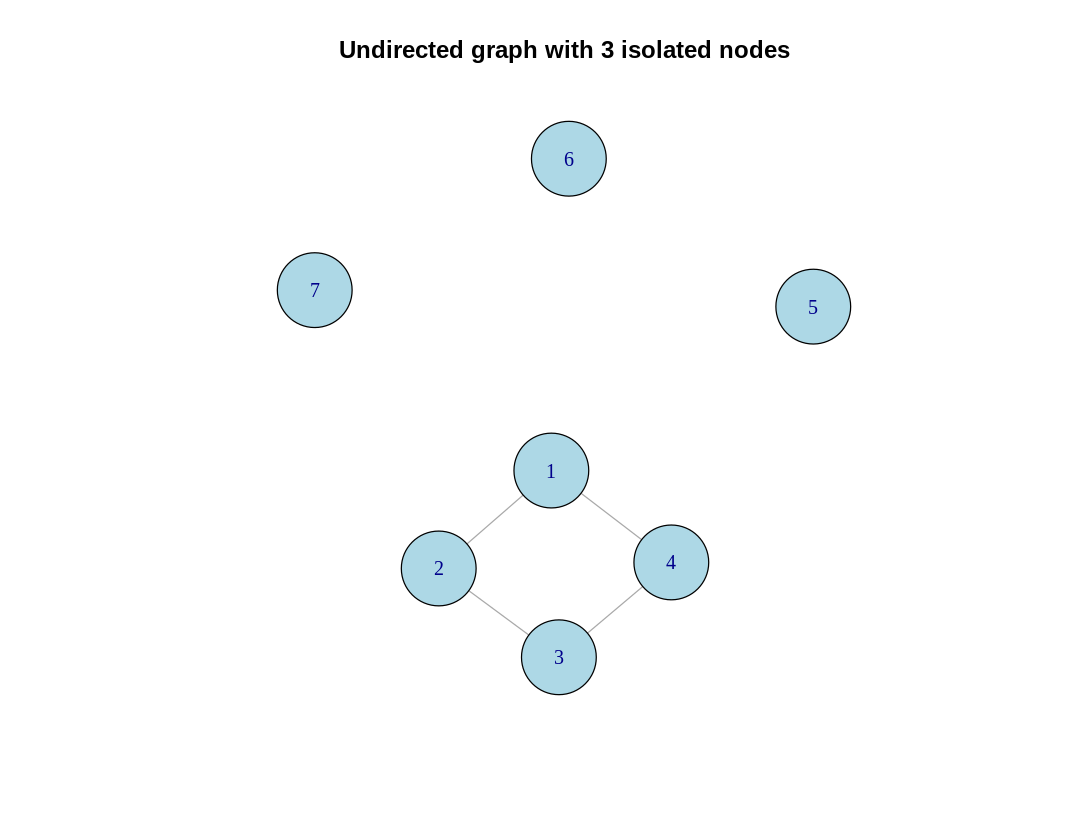

In [5]:
plot(g, vertex.color = "lightblue", vertex.size = 30,
     main = "Undirected graph with 3 isolated nodes")

A named, directed graph. Direction matters here: `"Amy", "Ram"` means Amy points to
Ram, not the reverse.

In [6]:
g1 <- make_graph(c("Amy", "Ram",
                   "Ram", "Li",
                   "Li",  "Amy",
                   "Amy", "Li",
                   "Kate","Li"),
                 directed = TRUE)
g1

IGRAPH 470186b DN-- 4 5 -- 
+ attr: name (v/c)
+ edges from 470186b (vertex names):
[1] Amy ->Ram Ram ->Li  Li  ->Amy Amy ->Li  Kate->Li 

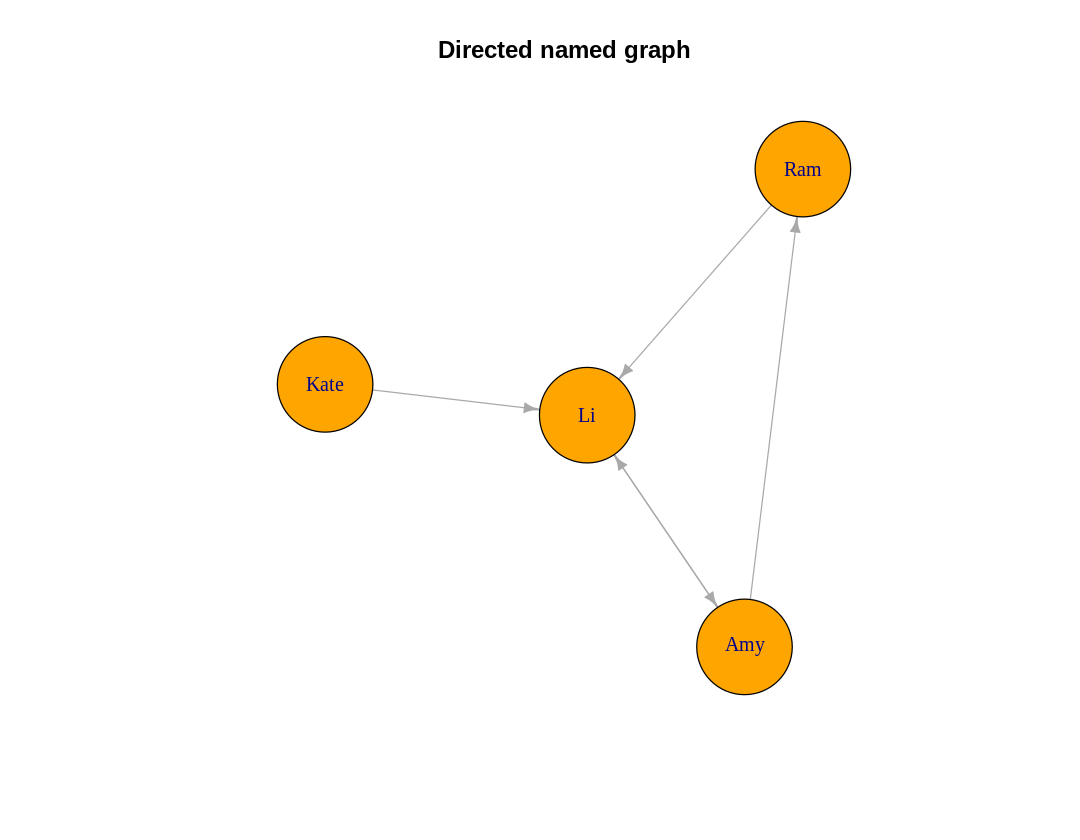

In [7]:
plot(g1, vertex.color = "orange", vertex.size = 40,
     edge.arrow.size = 0.6,
     main = "Directed named graph")

### Network measures on the small graph

**Degree** counts a node's connections. In a directed graph, in-degree counts arrows
received and out-degree counts arrows sent, so the two describe different roles.

In [8]:
degree(g1, mode = "all")

Amy  Ram   Li Kate 
   3    2    4    1

In [9]:
degree(g1, mode = "in")

Amy  Ram   Li Kate 
   1    1    3    0

In [10]:
degree(g1, mode = "out")

Amy  Ram   Li Kate 
   2    1    1    1

**Diameter** is the longest shortest-path in the network, so it measures how far
apart the two most distant nodes are.

In [11]:
diameter(g1, directed = FALSE, weights = NA)

[1] 2

**Edge density** is the proportion of possible connections that actually exist.
A value of 1 would mean everyone is connected to everyone.

In [12]:
edge_density(g1, loops = FALSE)

[1] 0.4166667

In [13]:
# The same quantity computed manually, to show what edge_density() does
ecount(g1) / (vcount(g1) * (vcount(g1) - 1))

[1] 0.4166667

**Reciprocity** is the proportion of directed edges that are returned. High
reciprocity means relationships tend to be mutual rather than one-way.

In [14]:
reciprocity(g1)

[1] 0.4

**Closeness** measures how near a node is to all others. A node with high closeness
can reach the rest of the network in few steps.

In [15]:
closeness(g1, mode = "all", weights = NA)

Amy       Ram        Li      Kate 
0.2500000 0.2500000 0.3333333 0.2000000

**Betweenness** counts how often a node lies on the shortest path between two other
nodes. High betweenness marks a broker: information between groups has to pass
through it.

In [16]:
betweenness(g1, directed = TRUE, weights = NA)

Amy  Ram   Li Kate 
   2    0    3    0

In [17]:
edge_betweenness(g1, directed = TRUE, weights = NA)

[1] 3 2 5 1 3

---
## Part 2: The real network dataset

The dataset records directed relationships between entities in two columns, `first`
and `second`. Each row is one edge.

In [18]:
data <- read.csv(
  "https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv",
  header = TRUE)

str(data)

'data.frame':	290 obs. of  4 variables:
 $ first : chr  "AA" "AB" "AF" "DD" ...
 $ second: chr  "DD" "DD" "BA" "DA" ...
 $ grade : int  6 6 6 6 6 6 6 6 6 6 ...
 $ spec  : chr  "Y" "R" "Q" "Q" ...


In [19]:
head(data, 10)

,first,second,grade,spec
,<chr>,<chr>,<int>,<chr>
1,AA,DD,6,Y
2,AB,DD,6,R
3,AF,BA,6,Q
4,DD,DA,6,Q
5,CD,EC,6,X
6,DD,CE,6,Y
7,CD,FA,6,X
8,CD,CC,6,W
9,BA,AF,6,R


In [20]:
cat("Rows (edges):", nrow(data), "\n")
cat("Unique nodes:", length(unique(c(data$first, data$second))), "\n")

Rows (edges): 290 
Unique nodes: 52 


Only the first two columns define the network structure. `grade` and `spec` are
attributes carried alongside and are not used to build the graph.

In [21]:
y <- data.frame(data$first, data$second)
head(y)

,data.first,data.second
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE


### Constructing the network

`graph_from_data_frame()` treats the first two columns as the edge list and creates
vertices automatically from the values it finds.

In [22]:
net <- graph_from_data_frame(y, directed = TRUE)
net

IGRAPH c5e579a DN-- 52 290 -- 
+ attr: name (v/c)
+ edges from c5e579a (vertex names):
 [1] AA->DD AB->DD AF->BA DD->DA CD->EC DD->CE CD->FA CD->CC BA->AF CB->CA
[11] CC->CA CD->CA BC->CA DD->DA ED->AD AE->AC AB->BA CD->EC CA->CC EB->CC
[21] BF->CE BB->CD AC->AE CC->FB DC->BB BD->CF DB->DA DD->DA DB->DD BC->AF
[31] CF->DE DF->BF CB->CA BE->CA EA->CA CB->CA CB->CA CC->CA CD->CA BC->CA
[41] BF->CA CE->CA AC->AD BD->BE AE->DF CB->DF AC->DF AA->DD AA->DD AA->DD
[51] CD->DD AA->DD EE->DD CD->DD DB->AA AA->FC BE->CC EF->FD CF->FE BB->DD
[61] CD->DD BA->AB CD->EC BE->EE CE->CC CD->CC ED->CC BB->CC BE->CE DD->CE
[71] AC->CD ED->CD FF->CD AC->CD DD->CD DD->CD AE->GA AE->GA AE->GA AE->GA
+ ... omitted several edges

In [23]:
cat("Vertices:", vcount(net), "\n")
cat("Edges:   ", ecount(net), "\n")

Vertices: 52 
Edges:    290 


Two attributes are attached to every vertex: its name as a printable label, and its
degree, which is used later to size nodes in the plots.

In [24]:
V(net)$label  <- V(net)$name
V(net)$degree <- degree(net)

head(V(net)$name)
head(V(net)$degree)

[1] "AA" "AB" "AF" "DD" "CD" "BA"

[1] 18  9 23 36 40 26

---
## Degree distribution

In [25]:
summary(V(net)$degree)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    1.00    6.50   11.15   18.50   62.00 

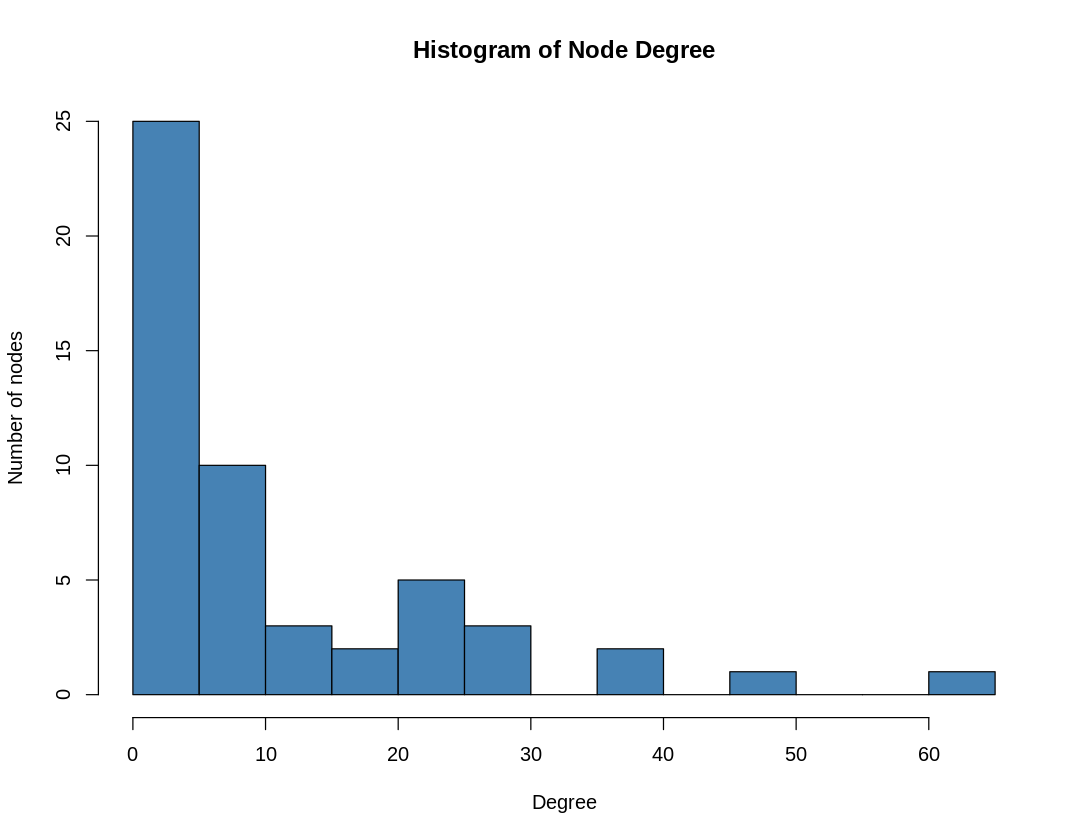

In [26]:
hist(V(net)$degree,
     breaks = 15,
     col = "steelblue",
     main = "Histogram of Node Degree",
     xlab = "Degree",
     ylab = "Number of nodes")

In [27]:
png("output/degree_histogram.png", width = 800, height = 550)
hist(V(net)$degree, breaks = 15, col = "steelblue",
     main = "Histogram of Node Degree", xlab = "Degree", ylab = "Number of nodes")
dev.off()
cat("saved output/degree_histogram.png\n")

agg_record_2a06c9aa005 
                     2

saved output/degree_histogram.png


The distribution is right-skewed: most nodes hold a small number of connections
while a few hold many. That shape is characteristic of real social networks and is
what makes identifying the highly connected minority worthwhile.

---
## Network visualisation

The default plot first, without any styling.

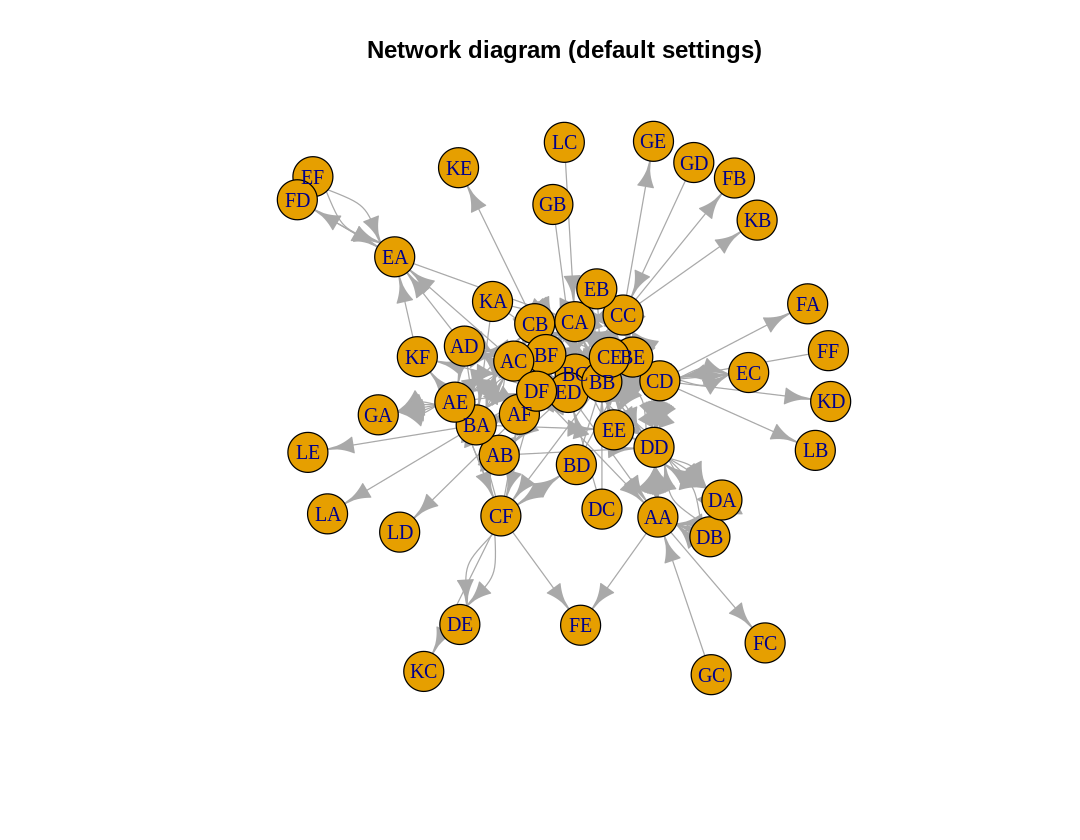

In [28]:
set.seed(123)
plot(net, main = "Network diagram (default settings)")

The default is unreadable at this size: labels overlap and arrowheads dominate.
Sizing each vertex by its degree, shrinking the arrows and choosing a
force-directed layout makes the structure visible.

`layout_with_fr` is the Fruchterman-Reingold algorithm, which treats edges as
springs so that connected nodes are drawn together and unconnected ones apart.

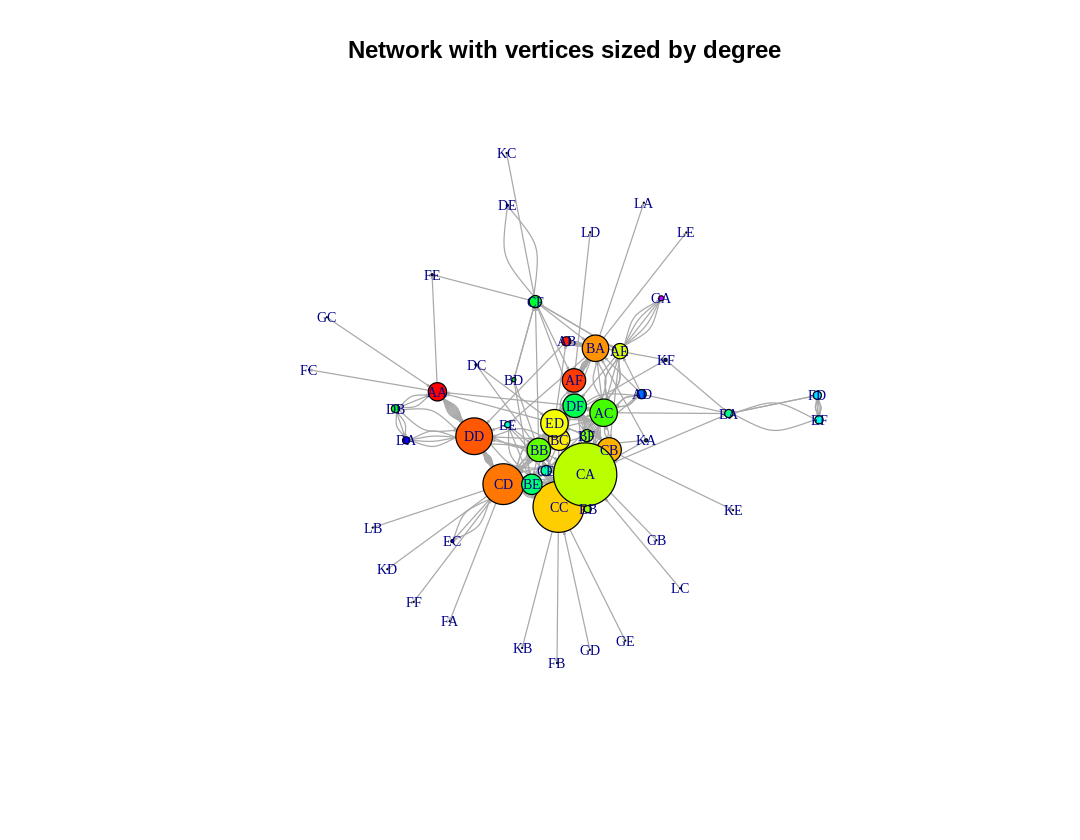

In [29]:
set.seed(123)
plot(net,
     vertex.color     = rainbow(52),
     vertex.size      = V(net)$degree * 0.4,
     vertex.label.cex = 0.7,
     edge.arrow.size  = 0.1,
     layout           = layout_with_fr,
     main             = "Network with vertices sized by degree")

In [30]:
png("output/network_degree.png", width = 1000, height = 800)
set.seed(123)
plot(net, vertex.color = rainbow(52), vertex.size = V(net)$degree * 0.4,
     vertex.label.cex = 0.7, edge.arrow.size = 0.1, layout = layout_with_fr,
     main = "Network with vertices sized by degree")
dev.off()
cat("saved output/network_degree.png\n")

agg_record_2a02ffd040b 
                     2

saved output/network_degree.png


---
## Hubs and authorities

Kleinberg's HITS algorithm assigns each node two scores. A **hub** points to many
well-regarded nodes; an **authority** is pointed to by many good hubs. In a directed
network the two capture opposite roles, so a node can score highly on one and poorly
on the other.

The tutorial calls `hub_score()` and `authority.score()` separately. Both are
deprecated, replaced by a single `hits_scores()` call returning both vectors. That
is also more efficient, since obtaining one score makes the other cheap to compute.

In [31]:
# Tutorial (deprecated):
#   hs <- hub_score(net)$vector
#   as <- authority.score(net)$vector

scores <- hits_scores(net)
hs <- scores$hub
as <- scores$authority

head(sort(hs, decreasing = TRUE))

CC        CB        CD        BC        BE        AC 
1.0000000 0.7145888 0.2350165 0.2321828 0.2195271 0.2093518

In [32]:
head(sort(as, decreasing = TRUE))

CA         DF         DD         CC         BE         AF 
1.00000000 0.19256499 0.14096985 0.11219410 0.10951546 0.08375004

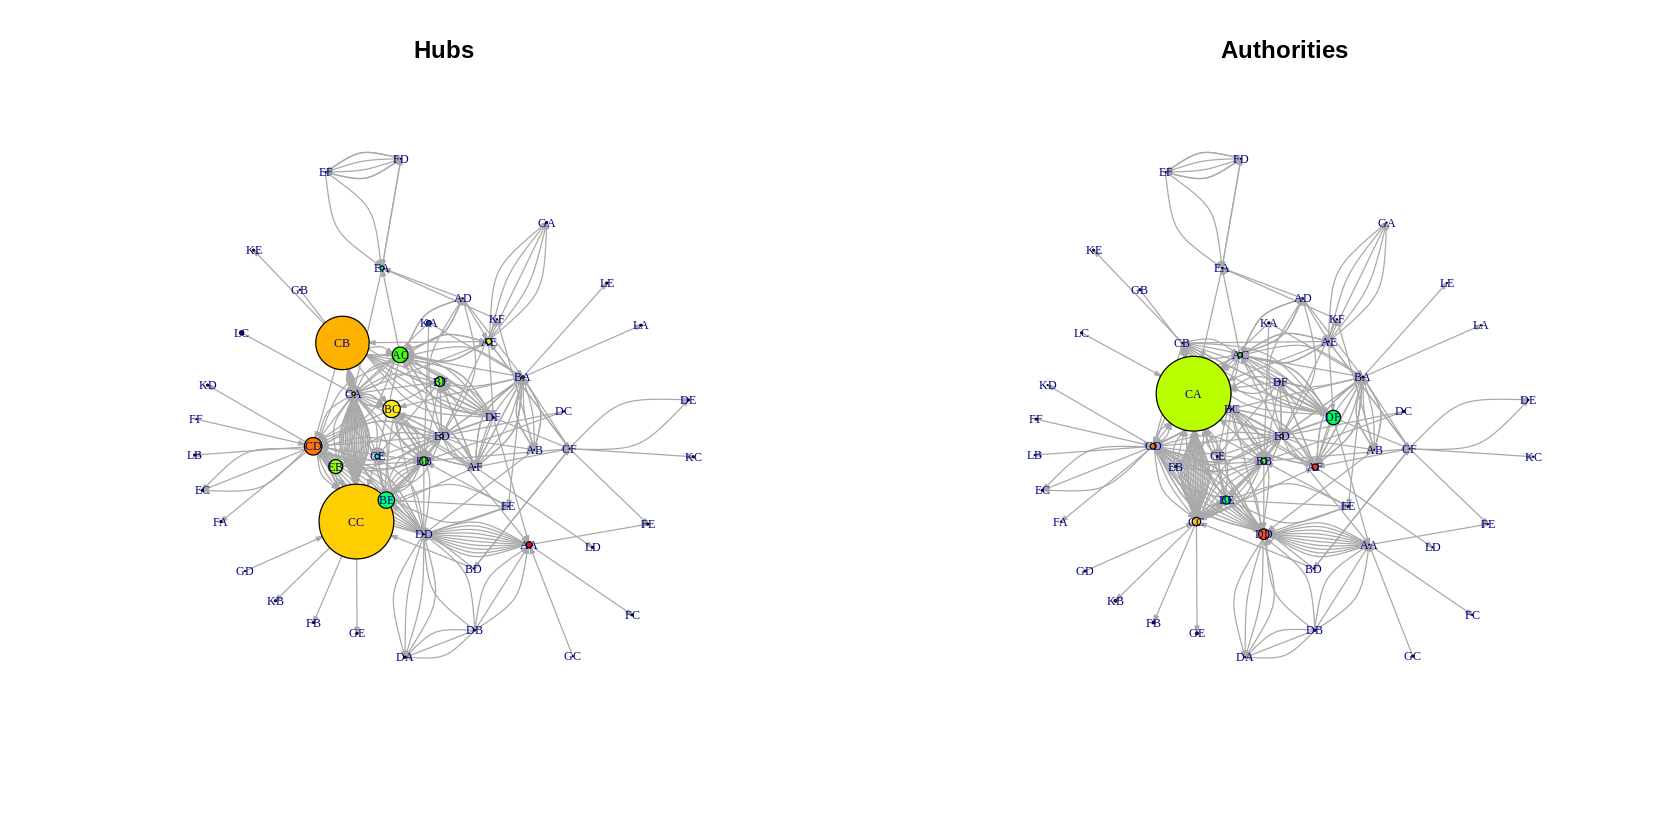

In [33]:
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2))
set.seed(123)
plot(net, vertex.size = hs * 30, main = "Hubs",
     vertex.color = rainbow(52), vertex.label.cex = 0.6,
     edge.arrow.size = 0.1, layout = layout_with_kk)

set.seed(123)
plot(net, vertex.size = as * 30, main = "Authorities",
     vertex.color = rainbow(52), vertex.label.cex = 0.6,
     edge.arrow.size = 0.1, layout = layout_with_kk)
par(mfrow = c(1, 1))
options(repr.plot.width = 9, repr.plot.height = 7)

In [34]:
png("output/hubs_authorities.png", width = 1400, height = 700)
par(mfrow = c(1, 2))
set.seed(123)
plot(net, vertex.size = hs * 30, main = "Hubs", vertex.color = rainbow(52),
     vertex.label.cex = 0.6, edge.arrow.size = 0.1, layout = layout_with_kk)
set.seed(123)
plot(net, vertex.size = as * 30, main = "Authorities", vertex.color = rainbow(52),
     vertex.label.cex = 0.6, edge.arrow.size = 0.1, layout = layout_with_kk)
par(mfrow = c(1, 1))
dev.off()
cat("saved output/hubs_authorities.png\n")

agg_record_2a061bafa28 
                     2

saved output/hubs_authorities.png


---
## Identifying influential nodes

Different measures answer different questions, so a node that leads on one may not
lead on another. All four are collected into one table and compared.

In [35]:
influence <- data.frame(
  Node        = V(net)$name,
  Degree      = degree(net, mode = "all"),
  InDegree    = degree(net, mode = "in"),
  OutDegree   = degree(net, mode = "out"),
  Betweenness = round(betweenness(net, directed = TRUE, weights = NA), 2),
  Closeness   = round(closeness(net, mode = "all", weights = NA), 5),
  Hub         = round(hs, 4),
  Authority   = round(as, 4),
  row.names   = NULL
)

head(influence[order(-influence$Degree), ], 10)

,Node,Degree,InDegree,OutDegree,Betweenness,Closeness,Hub,Authority
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,CA,62,50,12,292.16,0.01000,0.0449,1.0000
8,CC,50,25,25,225.27,0.00971,1.0000,0.1122
5,CD,40,15,25,375.99,0.01010,0.2350,0.0789
4,DD,36,28,8,162.99,0.00877,0.0126,0.1410
10,ED,27,10,17,343.02,0.01064,0.0486,0.0480
16,AC,27,12,15,172.43,0.00943,0.2094,0.0626
6,BA,26,13,13,184.50,0.00917,0.0324,0.0215
7,CB,24,2,22,36.24,0.00847,0.7146,0.0037
3,AF,23,16,7,109.76,0.00943,0.0047,0.0838


In [36]:
cat("--- Top 5 by total degree (most connections) ---\n")
print(head(influence[order(-influence$Degree), c("Node","Degree","InDegree","OutDegree")], 5))

cat("\n--- Top 5 by betweenness (brokers between groups) ---\n")
print(head(influence[order(-influence$Betweenness), c("Node","Betweenness","Degree")], 5))

cat("\n--- Top 5 by hub score (point to many authorities) ---\n")
print(head(influence[order(-influence$Hub), c("Node","Hub","OutDegree")], 5))

cat("\n--- Top 5 by authority score (pointed to by many hubs) ---\n")
print(head(influence[order(-influence$Authority), c("Node","Authority","InDegree")], 5))

--- Top 5 by total degree (most connections) ---
   Node Degree InDegree OutDegree
12   CA     62       50        12
8    CC     50       25        25
5    CD     40       15        25
4    DD     36       28         8
10   ED     27       10        17

--- Top 5 by betweenness (brokers between groups) ---
   Node Betweenness Degree
5    CD      375.99     40
10   ED      343.02     27
12   CA      292.16     62
15   BB      244.96     23
8    CC      225.27     50

--- Top 5 by hub score (point to many authorities) ---
   Node    Hub OutDegree
8    CC 1.0000        25
7    CB 0.7146        22
5    CD 0.2350        25
9    BC 0.2322        14
22   BE 0.2195        15

--- Top 5 by authority score (pointed to by many hubs) ---
   Node Authority InDegree
12   CA    1.0000       50
21   DF    0.1926       10
4    DD    0.1410       28
8    CC    0.1122       25
22   BE    0.1095        5


In [37]:
write.csv(influence[order(-influence$Degree), ],
          "output/node_measures.csv", row.names = FALSE)
cat("saved output/node_measures.csv\n")

saved output/node_measures.csv


---
## Network-level measures

In [38]:
net_measures <- data.frame(
  Measure = c("Nodes", "Edges", "Diameter", "Edge density",
              "Reciprocity", "Mean degree", "Transitivity (clustering)",
              "Connected components"),
  Value = c(
    vcount(net),
    ecount(net),
    diameter(net, directed = FALSE, weights = NA),
    round(edge_density(net, loops = FALSE), 5),
    round(reciprocity(net), 5),
    round(mean(degree(net, mode = "all")), 3),
    round(transitivity(net, type = "global"), 5),
    components(net)$no
  )
)
net_measures

Measure,Value
<chr>,<dbl>
Nodes,52.00000
Edges,290.00000
Diameter,5.00000
Edge density,0.10935
Reciprocity,0.29655
Mean degree,11.15400
Transitivity (clustering),0.26919
Connected components,1.00000


In [39]:
write.csv(net_measures, "output/network_measures.csv", row.names = FALSE)
cat("saved output/network_measures.csv\n")

saved output/network_measures.csv


---
## Community detection

Communities are groups with dense connections inside and sparse connections between.
The edge-betweenness method (Girvan-Newman) works by repeatedly removing the edge
that the most shortest paths run through, on the reasoning that such edges are the
bridges holding separate groups together.

Direction is dropped here because community structure is about who is connected to
whom, not who initiated the connection.

In [40]:
net_und <- graph_from_data_frame(y, directed = FALSE)
cnet <- cluster_edge_betweenness(net_und)
cnet

IGRAPH clustering edge betweenness, groups: 26, mod: 0.35
+ groups:
  $`1`
  [1] "AA" "DD" "CD" "ED" "DB" "DA" "EC"
  
  $`2`
  [1] "AB" "AF" "BA" "BC"
  
  $`3`
   [1] "CB" "CC" "CA" "EB" "BF" "BB" "DF" "BE" "CE" "EE"
  
  $`4`
  + ... omitted several groups/vertices

In [41]:
cat("Number of communities:", length(cnet), "\n")
cat("Modularity:", round(modularity(cnet), 4), "\n\n")
cat("Community sizes:\n")
print(sizes(cnet))

Number of communities: 26 
Modularity: 0.3514 

Community sizes:
Community sizes
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 
 7  4 10  4  1  3  4  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 


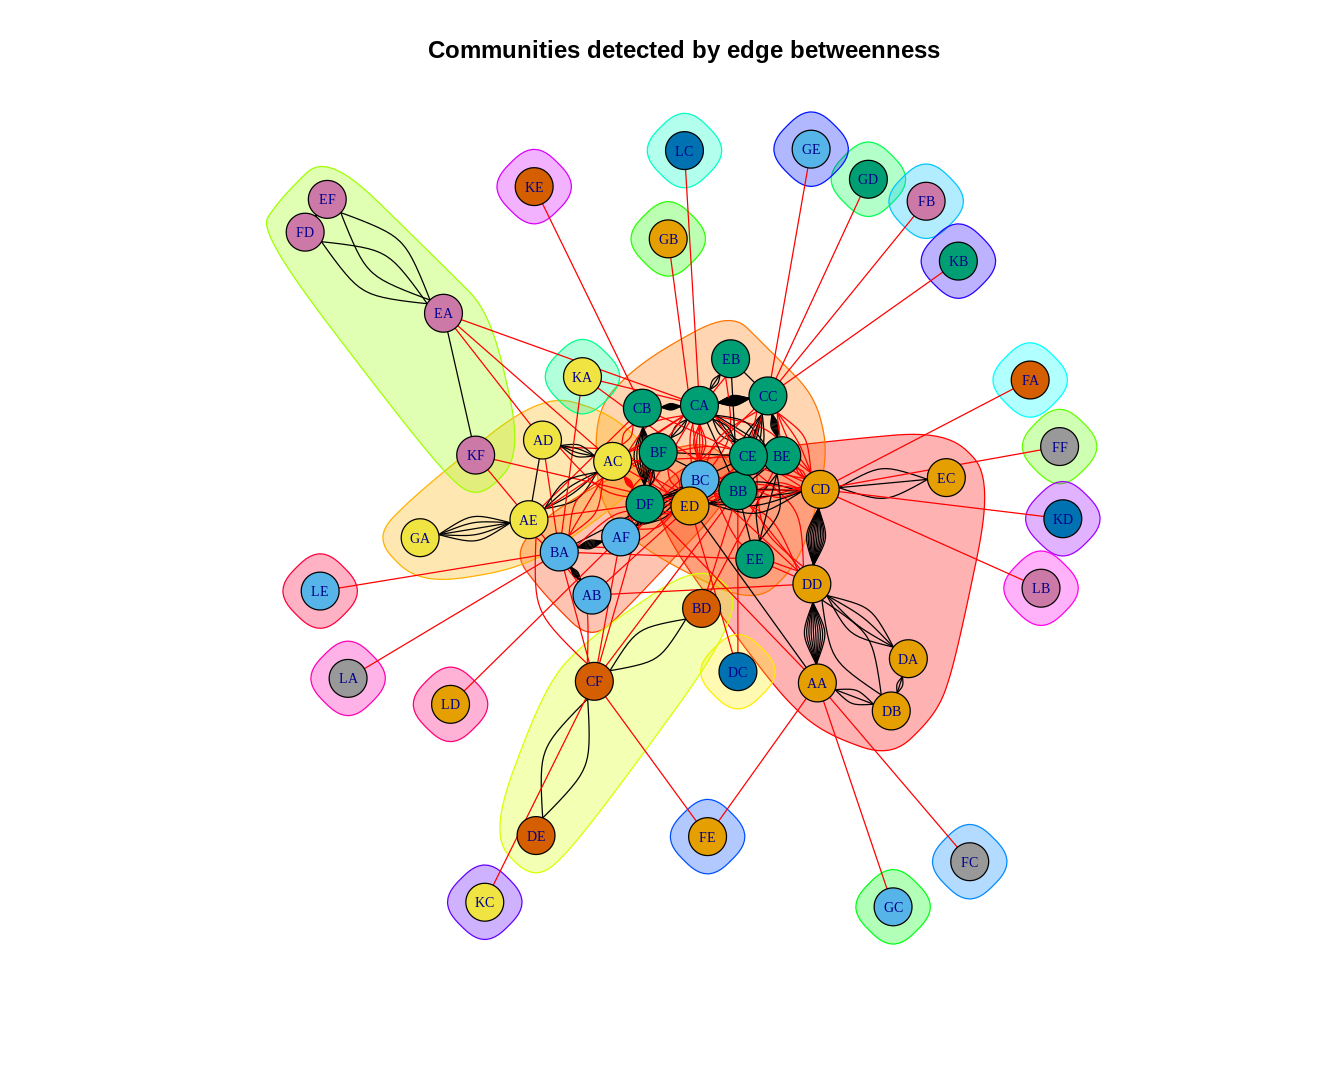

In [42]:
options(repr.plot.width = 11, repr.plot.height = 9)
set.seed(123)
plot(cnet, net_und,
     vertex.size      = 10,
     vertex.label.cex = 0.7,
     main             = "Communities detected by edge betweenness")
options(repr.plot.width = 9, repr.plot.height = 7)

In [43]:
png("output/communities.png", width = 1100, height = 900)
set.seed(123)
plot(cnet, net_und, vertex.size = 10, vertex.label.cex = 0.7,
     main = "Communities detected by edge betweenness")
dev.off()
cat("saved output/communities.png\n")

agg_record_2a01a6d1d74 
                     2

saved output/communities.png


In [44]:
membership_df <- data.frame(Node = V(net_und)$name,
                            Community = as.vector(membership(cnet)))
write.csv(membership_df[order(membership_df$Community), ],
          "output/community_membership.csv", row.names = FALSE)
head(membership_df[order(membership_df$Community), ], 15)

,Node,Community
,<chr>,<dbl>
1,AA,1
4,DD,1
5,CD,1
10,ED,1
19,DB,1
36,DA,1
37,EC,1
2,AB,2
3,AF,2


---
## Save and download

The cell below zips the results folder so everything can be pulled down in one file
from the sidebar.

In [45]:
list.files("output")

[1] "communities.png"          "community_membership.csv"
[3] "degree_histogram.png"     "hubs_authorities.png"    
[5] "network_degree.png"       "network_measures.csv"    
[7] "node_measures.csv"

In [46]:
system("zip -r assignment5_output.zip output", intern = FALSE)
cat("created assignment5_output.zip\n")

created assignment5_output.zip


---
## Interpretation

*Fill the bracketed values from the output above once the notebook has run.*

**Structure of the network.** The network holds 52 nodes joined by 290 directed edges.
Edge density is low, meaning only a small fraction of all possible connections are
present, which is typical: people in a real social setting connect to a handful of
others rather than to everyone. The degree histogram is right-skewed, so a small
number of nodes carry a disproportionate share of the connections while most nodes sit
in the tail.

**Who is important, and why the answer depends on the question.** Degree identifies the
most connected nodes, but connection count alone is a shallow notion of influence.
Betweenness identifies a different kind of importance: a node with modest degree can
still hold high betweenness if it is the only link between two otherwise separate
groups. Removing such a broker fragments the network in a way that removing a
high-degree node inside a dense cluster would not. Where the top of the degree ranking
and the top of the betweenness ranking disagree, the disagreement is the informative
part.

**Hubs against authorities.** Because the network is directed, the two HITS scores
separate two roles. A hub sends many connections towards well-regarded nodes; an
authority receives connections from many good hubs. In an advice or communication
network the hubs are the nodes that reach out, and the authorities are the nodes people
turn to. A node ranking highly on both is unusual and worth noting.

**Community structure.** Edge-betweenness detection partitions the network into
communities with dense internal and sparse external connections. Modularity quantifies
how clean that separation is, with values above roughly 0.3 indicating genuine
structure rather than an artefact of the algorithm, which will always return some
partition whether or not one exists.

**Limitations.** Every measure here is computed on a single static snapshot, so nothing
can be said about how these relationships formed or whether they persist. Centrality
scores describe position within this observed network only; a node with low degree here
may be central in a network that was not recorded. The edge-betweenness algorithm is
also comparatively slow and would not scale to a network of thousands of nodes, where
Louvain or Leiden clustering would be preferred.